<a href="https://colab.research.google.com/github/paul195samudra/Fraud-Detection-In-Bank-Transaction/blob/main/Fraud_Detection_in_Bank_Transactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fraud Detection Analysis: Exploring Banking Transaction Data

This notebook presents an **exploratory data analysis** (EDA) of banking transaction data to identify patterns and characteristics associated with fraudulent activities.





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/FraudShield_Banking_Data.csv")

# Initial Data Inspection

In [ ]:
df.head()


,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_ID                         49997 non-null  float64
 1   Customer_ID                            49990 non-null  float64
 2   Transaction_Amount (in Million)        49991 non-null  float64
 3   Transaction_Time                       49991 non-null  object 
 4   Transaction_Date                       49997 non-null  object 
 5   Transaction_Type                       49996 non-null  object 
 6   Merchant_ID                            49993 non-null  float64
 7   Merchant_Category                      49991 non-null  object 
 8   Transaction_Location                   49994 non-null  object 
 9   Customer_Home_Location                 49996 non-null  object 
 10  Distance_From_Home                     49998 non-null  float64
 11  De

In [ ]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Transaction_Amount (in Million)',
       'Transaction_Time', 'Transaction_Date', 'Transaction_Type',
       'Merchant_ID', 'Merchant_Category', 'Transaction_Location',
       'Customer_Home_Location', 'Distance_From_Home', 'Device_ID',
       'IP_Address', 'Card_Type', 'Account_Balance (in Million)',
       'Daily_Transaction_Count', 'Weekly_Transaction_Count',
       'Avg_Transaction_Amount (in Million)',
       'Max_Transaction_Last_24h (in Million)', 'Is_International_Transaction',
       'Is_New_Merchant', 'Failed_Transaction_Count',
       'Unusual_Time_Transaction', 'Previous_Fraud_Count', 'Fraud_Label'],
      dtype='object')

#  Fraud Label and Distribution Analysis

Examined the distribution of the Fraud_Label to understand the balance between normal and fraudulent transactions. A numeric Fraud_Label_Numeric column is created for easier quantitative analysis, mapping 'Normal' to 0 and 'Fraud' to 1.

In [ ]:
print("Distribution of Fraud_Label:")
display(df["Fraud_Label"].value_counts())

fraud_percentage = round((df["Fraud_Label"].value_counts().get('Fraud', 0) / df.shape[0]) * 100, 2)
print(f"\nPercentage of fraudulent transactions: {fraud_percentage}%")

df['Fraud_Label_Numeric'] = df['Fraud_Label'].map({'Normal': 0, 'Fraud': 1})
print("\nDistribution of Previous_Fraud_Count:")
display(df["Previous_Fraud_Count"].value_counts())

Distribution of Fraud_Label:


,count
Fraud_Label,
Normal,47573
Fraud,2423



Percentage of fraudulent transactions: 4.85%

Distribution of Previous_Fraud_Count:


,count
Previous_Fraud_Count,
1.0,25005
0.0,24992


## Transaction Type Analysis

This section focuses on understanding the different types of transactions and their relationship with fraudulent activities. We visualize the count of each transaction type and then analyze the fraud rate per transaction type.

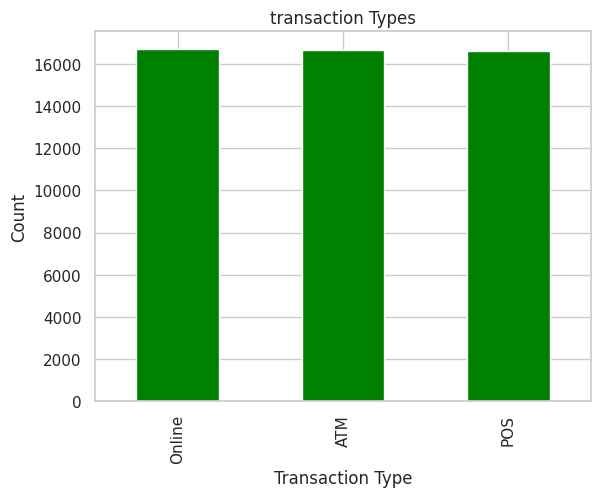

In [ ]:
df["Transaction_Type"].value_counts().plot(kind="bar", title="transaction Types", color="green")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

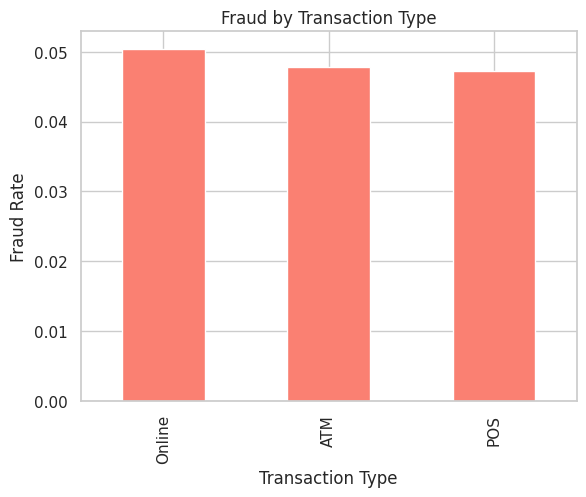

In [ ]:
df['Fraud_Label_Numeric'] = df['Fraud_Label'].map({'Normal': 0, 'Fraud': 1})
fraud_by_type = df.groupby("Transaction_Type")["Fraud_Label_Numeric"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud by Transaction Type",color="salmon")
plt.ylabel("Fraud Rate")
plt.xlabel("Transaction Type")
plt.show()

In [ ]:
df["Transaction_Amount (in Million)"].describe().astype(int)

,Transaction_Amount (in Million)
count,49991
mean,4
std,2
min,1
25%,3
50%,5
75%,7
max,9


#  Transaction Amount Analysis

Investigating the distribution of Transaction_Amount (in Million) and its relationship with fraud. We look at descriptive statistics, a histogram of log-transformed amounts, and a box plot comparing amount distributions for normal and fraudulent transactions.

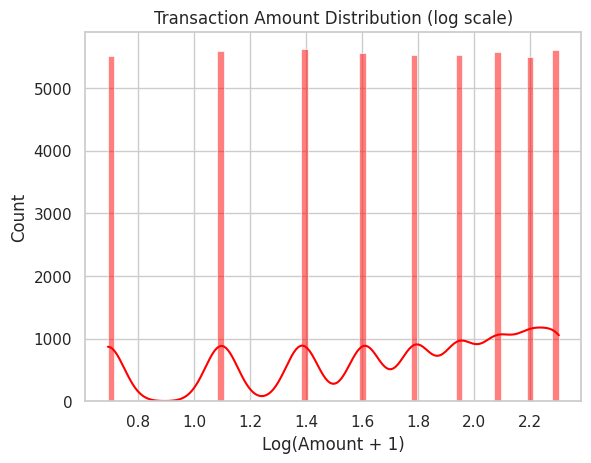

In [ ]:
sns.histplot(np.log1p(df["Transaction_Amount (in Million)"]),bins=70, kde=True, color="red")
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("Log(Amount + 1)")
plt.show()

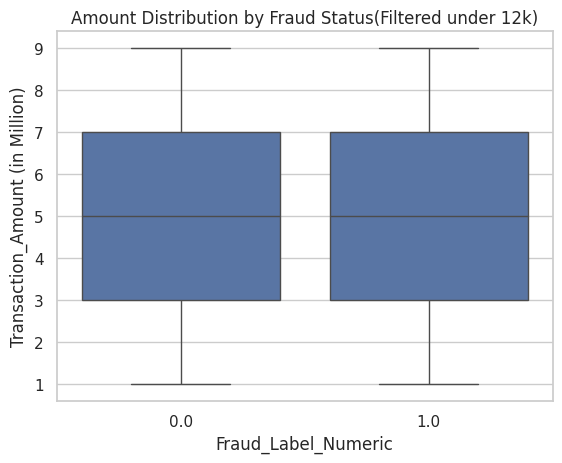

In [ ]:
sns.boxplot(data=df[df["Transaction_Amount (in Million)"]< 12000], x ="Fraud_Label_Numeric", y ="Transaction_Amount (in Million)")
plt.title("Amount Distribution by Fraud Status(Filtered under 12k)")
plt.show()

In [ ]:
df.head(2)

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label,Fraud_Label_Numeric
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal,0.0
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal,0.0


# Time-Series Analysis of Fraud

Analyzing the number of fraudulent transactions over time to identify any temporal patterns or trends.

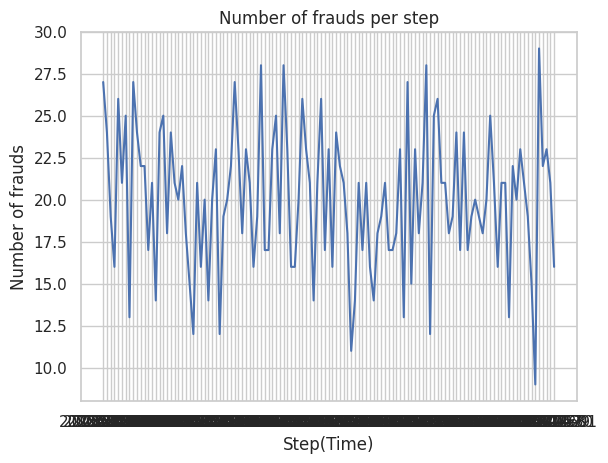

In [ ]:
frauds_per_step = df[df["Fraud_Label_Numeric"] == 1].groupby("Transaction_Date").size().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values,label = "frauds per step")
plt.xlabel("Step(Time)")
plt.ylabel("Number of frauds")
plt.title("Number of frauds per step")
plt.show()

In [ ]:
df.head(2)

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label,Fraud_Label_Numeric
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal,0.0
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal,0.0


# Top Customers

In [ ]:
top_senders = df["Customer_ID"].value_counts().head(10)
display(top_senders)

,count
Customer_ID,
15303.0,6
43223.0,6
10985.0,6
88220.0,6
62526.0,5
63233.0,5
61179.0,5
53513.0,5
29545.0,5


# Top Marchants

In [ ]:
top_receivers = df["Merchant_ID"].value_counts().head(10)
display(top_receivers)

,count
Merchant_ID,
43845.0,6
43566.0,6
74081.0,5
20897.0,5
50253.0,5
19293.0,5
22673.0,5
69147.0,5
80420.0,5


# Fraudulent Transactions (if any):



In [ ]:
fraud_users = df[df["Fraud_Label_Numeric"] == 1]["Customer_ID"].value_counts().head(10)

display(fraud_users)

,count
Customer_ID,
41045.0,3
42350.0,2
93976.0,2
62997.0,2
41816.0,2
80610.0,2
11835.0,2
60526.0,2
38450.0,2


# Analysis of Specific Transaction Patterns

Revewing transactions that might be suspicious, specifically focusing on Online, ATM, and POS transaction types. The previous attempt to filter based on balance changes (oldbalanceOrg, newbalanceOrig) was commented out as these columns do not exist in the current dataset, making zero_after_transfer identical to fraud_types.

In [ ]:
zero_after_transfer = df[
    (df["Transaction_Type"].isin(["Online", "ATM", "POS"]))
]
print("Transactions with Online, ATM, or POS types:")
display(zero_after_transfer.head())

Transactions with Online, ATM, or POS types:


,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label,Fraud_Label_Numeric
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal,0.0
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal,0.0
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal,0.0
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal,0.0
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal,0.0


In [ ]:
fraud_types = df[df["Transaction_Type"].isin(["Online", "ATM", "POS"])]

In [ ]:
fraud_types['Transaction_Type'].value_counts()

,count
Transaction_Type,
Online,16713
ATM,16682
POS,16601


Text(0, 0.5, 'Count')

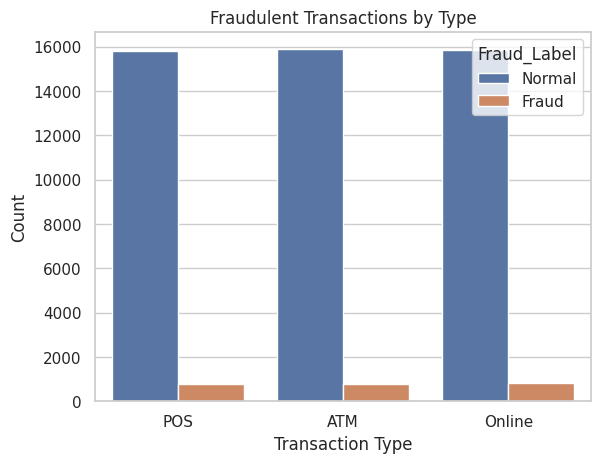

In [ ]:
sns.countplot(data=fraud_types, x="Transaction_Type", hue="Fraud_Label")
plt.title("Fraudulent Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

###  Advanced Feature Correlation and Importance

To get a more comprehensive understanding of feature relationships, especially for machine learning, using methods that can handle different data types and capture non-linear dependencies.

First, preparing the data by filling missing values and encoding categorical features. For simplicity, use median imputation for numerical features and mode imputation for categorical features. Then, apply one-hot encoding to handle categorical variables for some of the correlation methods and for model training.

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import scipy.stats as ss
from sklearn.feature_selection import mutual_info_classif

df_processed = df.copy()
for col in df_processed.select_dtypes(include=np.number).columns:
    if df_processed[col].isnull().any():
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

for col in df_processed.select_dtypes(include='object').columns:
    if df_processed[col].isnull().any():
        df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

print(df_processed.isnull().sum().sum())

id_columns = ['Transaction_ID', 'Customer_ID', 'Merchant_ID', 'Device_ID', 'IP_Address']
df_processed = df_processed.drop(columns=[col for col in id_columns if col in df_processed.columns])
df_processed['Transaction_Date'] = pd.to_datetime(df_processed['Transaction_Date'])
df_processed['day_of_week'] = df_processed['Transaction_Date'].dt.dayofweek
df_processed['month'] = df_processed['Transaction_Date'].dt.month
df_processed['day'] = df_processed['Transaction_Date'].dt.day

df_processed['Transaction_Time_Hour'] = pd.to_datetime(df_processed['Transaction_Time'], format='%H:%M').dt.hour

df_processed = df_processed.drop(columns=['Transaction_Date', 'Transaction_Time'])

categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Fraud_Label')

df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
if 'Fraud_Label_Numeric' not in df_encoded.columns and 'Fraud_Label' in df_encoded.columns:
    df_encoded['Fraud_Label_Numeric'] = df_encoded['Fraud_Label'].map({'Normal': 0, 'Fraud': 1})

if 'Fraud_Label_Numeric' in df_encoded.columns and 'Fraud_Label' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['Fraud_Label'])

display(df_encoded.head())


0


,Transaction_Amount (in Million),Distance_From_Home,Account_Balance (in Million),Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Failed_Transaction_Count,Previous_Fraud_Count,Fraud_Label_Numeric,...,Transaction_Location_Multan,Transaction_Location_Singapore,Customer_Home_Location_Islamabad,Customer_Home_Location_Karachi,Customer_Home_Location_Lahore,Customer_Home_Location_Multan,Card_Type_Debit,Is_International_Transaction_Yes,Is_New_Merchant_Yes,Unusual_Time_Transaction_Yes
0,6.0,466.0,30.0,4.0,17.0,2.0,4.0,0.0,1.0,0.0,...,False,True,False,False,True,False,False,True,True,False
1,9.0,215.0,4.0,4.0,9.0,5.0,8.0,1.0,1.0,0.0,...,False,True,False,False,True,False,False,True,True,False
2,3.0,216.0,38.0,5.0,18.0,5.0,8.0,0.0,1.0,0.0,...,False,False,False,False,False,False,True,True,False,True
3,1.0,408.0,22.0,6.0,18.0,5.0,1.0,2.0,1.0,0.0,...,False,False,False,True,False,False,True,False,True,True
4,1.0,209.0,10.0,3.0,18.0,4.0,3.0,1.0,1.0,0.0,...,False,True,True,False,False,False,True,False,True,False


###  Cramer's V for Categorical-Categorical Association

Cramer's V is a measure of association between two nominal variables, ranges from 0 to 1

In [ ]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

categorical_features_original = [col for col in df_processed.select_dtypes(include='object').columns if col != 'Fraud_Label']
categorical_features_original.extend(['day_of_week', 'month', 'day', 'Transaction_Time_Hour'])

cramer_v_results = {}
for col in categorical_features_original:
    cramer_v_results[col] = cramers_v(df_processed[col].astype('category'), df_processed['Fraud_Label'])

cramer_v_df = pd.DataFrame(list(cramer_v_results.items()), columns=['Feature', 'Cramers_V'])
cramer_v_df = cramer_v_df.sort_values(by='Cramers_V', ascending=False).reset_index(drop=True)
display(cramer_v_df)


,Feature,Cramers_V
0,Is_International_Transaction,0.059964
1,Unusual_Time_Transaction,0.059539
2,day_of_week,0.016134
3,Transaction_Type,0.001875
4,Transaction_Time_Hour,0.001463
5,Customer_Home_Location,0.000000
6,Merchant_Category,0.000000
7,Transaction_Location,0.000000
8,Is_New_Merchant,0.000000
9,Card_Type,0.000000


###  Mutual Information for Feature Selection

Mutual Information measures the reduction in uncertainty about one variable given another. It's a non-parametric measure, making it suitable for capturing non-linear relationships. Higher values indicate greater dependency. We'll calculate it for all features (numerical and encoded categorical) against the Fraud_Label_Numeric.

In [ ]:
X = df_encoded.drop(columns=['Fraud_Label_Numeric'])
y = df_encoded['Fraud_Label_Numeric']

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = pd.to_numeric(X[col], errors='coerce')

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns)
mi_series = mi_series.sort_values(ascending=False).reset_index()
mi_series.columns = ['Feature', 'Mutual_Information_Score']


display(mi_series.head(15))


,Feature,Mutual_Information_Score
0,Unusual_Time_Transaction_Yes,0.009894
1,Card_Type_Debit,0.008804
2,Is_International_Transaction_Yes,0.008122
3,Is_New_Merchant_Yes,0.006932
4,Previous_Fraud_Count,0.006285
5,Transaction_Type_POS,0.004443
6,Transaction_Type_Online,0.004072
7,Failed_Transaction_Count,0.003975
8,Avg_Transaction_Amount (in Million),0.003417
9,Customer_Home_Location_Lahore,0.002864


###  Feature Importance from a Random Forest Classifier



In [ ]:
X = df_encoded.drop(columns=['Fraud_Label_Numeric'])
y = df_encoded['Fraud_Label_Numeric']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False).reset_index()
feature_importances.columns = ['Feature', 'Importance']

display(feature_importances.head(15))


y_pred = rf_model.predict(X_test)
print(f"\n Accuracy: {accuracy_score(y_test, y_pred):.4f}")


,Feature,Importance
0,Distance_From_Home,0.098197
1,Account_Balance (in Million),0.078998
2,day,0.077013
3,Transaction_Time_Hour,0.074483
4,Weekly_Transaction_Count,0.073282
5,Transaction_Amount (in Million),0.054631
6,Max_Transaction_Last_24h (in Million),0.053967
7,day_of_week,0.047457
8,Daily_Transaction_Count,0.047233
9,Avg_Transaction_Amount (in Million),0.039339



 Accuracy: 0.9515


# Correlation Analysis

In [ ]:
corr = df[["Transaction_Amount (in Million)", "Account_Balance (in Million)", "Fraud_Label_Numeric"]].corr()


In [ ]:
corr

,Transaction_Amount (in Million),Account_Balance (in Million),Fraud_Label_Numeric
Transaction_Amount (in Million),1.000000,-0.003795,-0.001032
Account_Balance (in Million),-0.003795,1.000000,-0.006131
Fraud_Label_Numeric,-0.001032,-0.006131,1.000000


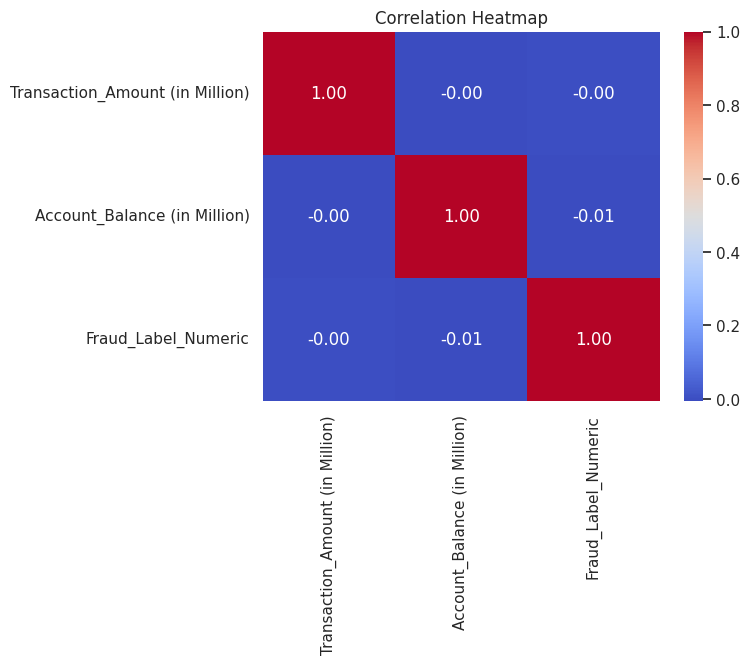

In [ ]:
sns.heatmap(corr, annot=True, cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# build custom model, use neural networks, try other pre-trained mode

# **XGBoost Algorithm**

Builds tree sequencially, each trees tries to connect the errors of the previous ones


---
Acts well on Tabular dataset


In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import mutual_info_classif

import scipy.stats as ss

from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv( "/content/drive/MyDrive/FraudShield_Banking_Data.csv")


In [ ]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_ID                         49997 non-null  float64
 1   Customer_ID                            49990 non-null  float64
 2   Transaction_Amount (in Million)        49991 non-null  float64
 3   Transaction_Time                       49991 non-null  object 
 4   Transaction_Date                       49997 non-null  object 
 5   Transaction_Type                       49996 non-null  object 
 6   Merchant_ID                            49993 non-null  float64
 7   Merchant_Category                      49991 non-null  object 
 8   Transaction_Location                   49994 non-null  object 
 9   Customer_Home_Location                 49996 non-null  object 
 10  Distance_From_Home                     49998 non-null  float64
 11  De

In [ ]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Transaction_Amount (in Million)',
       'Transaction_Time', 'Transaction_Date', 'Transaction_Type',
       'Merchant_ID', 'Merchant_Category', 'Transaction_Location',
       'Customer_Home_Location', 'Distance_From_Home', 'Device_ID',
       'IP_Address', 'Card_Type', 'Account_Balance (in Million)',
       'Daily_Transaction_Count', 'Weekly_Transaction_Count',
       'Avg_Transaction_Amount (in Million)',
       'Max_Transaction_Last_24h (in Million)', 'Is_International_Transaction',
       'Is_New_Merchant', 'Failed_Transaction_Count',
       'Unusual_Time_Transaction', 'Previous_Fraud_Count', 'Fraud_Label'],
      dtype='object')

# Fraud Label Analysis

In [ ]:
print("Distribution of Fraud_Label:")

display(
    df["Fraud_Label"].value_counts()
)

fraud_percentage = round(
    (
        df["Fraud_Label"]
        .value_counts()
        .get("Fraud", 0)
        / df.shape[0]
    ) * 100,
    2
)

print(
    f"\nFraudulent transactions: "
    f"{fraud_percentage}%"
)

Distribution of Fraud_Label:


,count
Fraud_Label,
Normal,47573
Fraud,2423



Fraudulent transactions: 4.85%


In [ ]:
df["Fraud_Label_Numeric"] = (
    df["Fraud_Label"]
    .map({
        "Normal": 0,
        "Fraud": 1
    })
)

print(
    "\nDistribution of Previous_Fraud_Count:"
)

display(
    df["Previous_Fraud_Count"].value_counts()
)


Distribution of Previous_Fraud_Count:


,count
Previous_Fraud_Count,
1.0,25005
0.0,24992


**Transaction type Analysis**

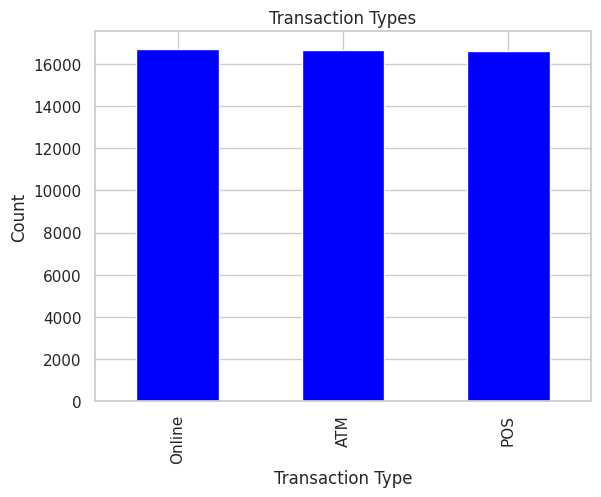

In [ ]:
df["Transaction_Type"].value_counts().plot(
    kind="bar",
    title="Transaction Types",
    color="blue"
)

plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

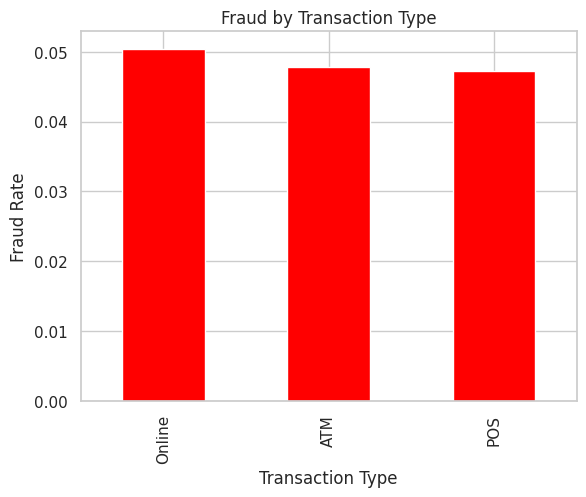

In [ ]:
fraud_by_type = (
    df.groupby("Transaction_Type")
    ["Fraud_Label_Numeric"]
    .mean()
    .sort_values(
        ascending=False
    )
)

fraud_by_type.plot(
    kind="bar",
    title="Fraud by Transaction Type",
    color="red"
)

plt.ylabel("Fraud Rate")
plt.xlabel("Transaction Type")

plt.show()

In [ ]:
df["Transaction_Amount (in Million)"].describe().astype(int)

,Transaction_Amount (in Million)
count,49991
mean,4
std,2
min,1
25%,3
50%,5
75%,7
max,9


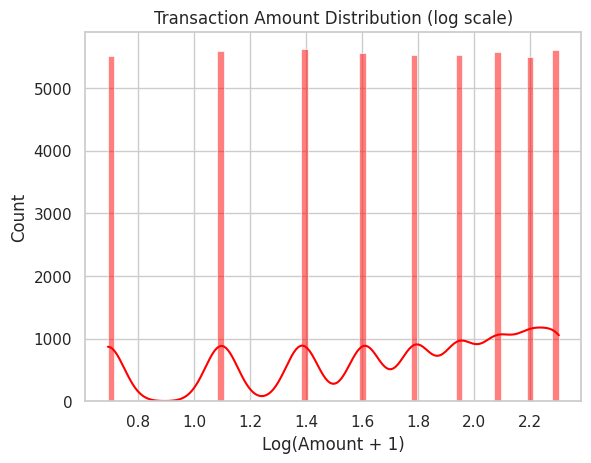

In [ ]:
sns.histplot(np.log1p(df["Transaction_Amount (in Million)"]),bins=70,kde=True,color="red")

plt.title(
    "Transaction Amount Distribution (log scale)"
)

plt.xlabel(
    "Log(Amount + 1)"
)

plt.show()

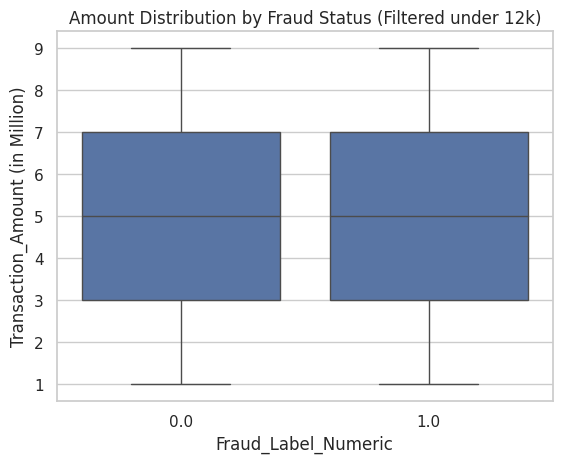

In [ ]:
sns.boxplot(data=df[df["Transaction_Amount (in Million)"] < 12000], x="Fraud_Label_Numeric",y="Transaction_Amount (in Million)")

plt.title(
    "Amount Distribution by Fraud Status "
    "(Filtered under 12k)"
)

plt.show()

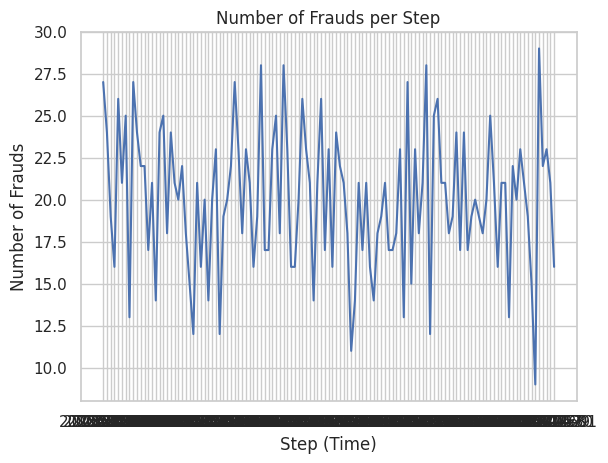

In [ ]:
frauds_per_step = (
    df[
        df["Fraud_Label_Numeric"] == 1
    ]
    .groupby("Transaction_Date")
    .size()
    .sort_index()
)

plt.plot(
    frauds_per_step.index,
    frauds_per_step.values,
    label="Frauds per step"
)

plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Number of Frauds per Step")

plt.show()

In [ ]:
top_senders = (
    df["Customer_ID"]
    .value_counts()
    .head(10)
)

display(
    top_senders
)

top_senders = (
    df["Customer_ID"]
    .value_counts()
    .head(10)
)

display(
    top_senders
)

fraud_users = (
    df[
        df["Fraud_Label_Numeric"] == 1
    ]["Customer_ID"]
    .value_counts()
    .head(10)
)

display(
    fraud_users
)

,count
Customer_ID,
15303.0,6
43223.0,6
10985.0,6
88220.0,6
62526.0,5
63233.0,5
61179.0,5
53513.0,5
29545.0,5


,count
Customer_ID,
15303.0,6
43223.0,6
10985.0,6
88220.0,6
62526.0,5
63233.0,5
61179.0,5
53513.0,5
29545.0,5


,count
Customer_ID,
41045.0,3
42350.0,2
93976.0,2
62997.0,2
41816.0,2
80610.0,2
11835.0,2
60526.0,2
38450.0,2


In [ ]:
zero_after_transfer = df[
    df["Transaction_Type"].isin(
        [
            "Online",
            "ATM",
            "POS"
        ]
    )
]

print(
    "Transactions with Online, ATM, or POS types:"
)

display(
    zero_after_transfer.head()
)

Transactions with Online, ATM, or POS types:


,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label,Fraud_Label_Numeric
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal,0.0
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal,0.0
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal,0.0
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal,0.0
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal,0.0


In [ ]:
fraud_types = df[
    df["Transaction_Type"].isin(
        [
            "Online",
            "ATM",
            "POS"
        ]
    )
]

fraud_types[
    "Transaction_Type"
].value_counts()

,count
Transaction_Type,
Online,16713
ATM,16682
POS,16601


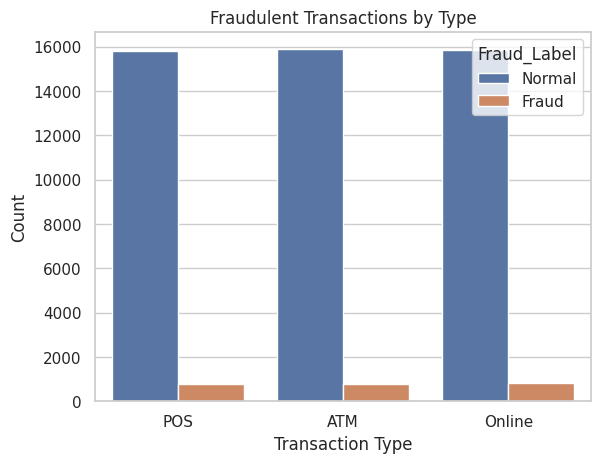

In [ ]:
sns.countplot(
    data=fraud_types,
    x="Transaction_Type",
    hue="Fraud_Label"
)

plt.title(
    "Fraudulent Transactions by Type"
)

plt.xlabel(
    "Transaction Type"
)

plt.ylabel(
    "Count"
)

plt.show()

In [ ]:
df_processed = df.copy()

In [ ]:
for col in (
    df_processed
    .select_dtypes(
        include=np.number
    )
    .columns
):

    if (
        df_processed[col]
        .isnull()
        .any()
    ):

        df_processed[col].fillna(
            df_processed[col].median(),
            inplace=True
        )

In [ ]:
for col in (
    df_processed
    .select_dtypes(
        include="object"
    )
    .columns
):

    if (
        df_processed[col]
        .isnull()
        .any()
    ):

        df_processed[col].fillna(
            df_processed[col].mode()[0],
            inplace=True
        )

print(
    df_processed
    .isnull()
    .sum()
    .sum()
)

0


In [ ]:
id_columns = [
    "Transaction_ID",
    "Customer_ID",
    "Merchant_ID",
    "Device_ID",
    "IP_Address"
]

df_processed = (
    df_processed
    .drop(
        columns=[
            col
            for col in id_columns
            if col in df_processed.columns
        ]
    )
)

In [ ]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label,Fraud_Label_Numeric
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal,0.0
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal,0.0
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal,0.0
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal,0.0
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal,0.0


In [ ]:
df_processed[
    "Transaction_Date"
] = pd.to_datetime(
    df_processed[
        "Transaction_Date"
    ]
)

df_processed[
    "day_of_week"
] = (
    df_processed[
        "Transaction_Date"
    ]
    .dt.dayofweek
)

df_processed[
    "month"
] = (
    df_processed[
        "Transaction_Date"
    ]
    .dt.month
)

df_processed[
    "day"
] = (
    df_processed[
        "Transaction_Date"
    ]
    .dt.day
)

In [ ]:
df_processed[
    "Transaction_Time_Hour"
] = pd.to_datetime(
    df_processed[
        "Transaction_Time"
    ],
    format="%H:%M"
).dt.hour

df_processed = (
    df_processed
    .drop(
        columns=[
            "Transaction_Date",
            "Transaction_Time"
        ]
    )
)

In [ ]:
categorical_cols = (
    df_processed
    .select_dtypes(
        include="object"
    )
    .columns
    .tolist()
)

categorical_cols.remove(
    "Fraud_Label"
)

df_encoded = pd.get_dummies(
    df_processed,
    columns=categorical_cols,
    drop_first=True
)

# Preparing Target Column

In [ ]:
if (
    "Fraud_Label_Numeric"
    not in df_encoded.columns
    and
    "Fraud_Label"
    in df_encoded.columns
):

    df_encoded[
        "Fraud_Label_Numeric"
    ] = (
        df_encoded[
            "Fraud_Label"
        ]
        .map({
            "Normal": 0,
            "Fraud": 1
        })
    )

if (
    "Fraud_Label_Numeric"
    in df_encoded.columns
    and
    "Fraud_Label"
    in df_encoded.columns
):

    df_encoded = (
        df_encoded
        .drop(
            columns=[
                "Fraud_Label"
            ]
        )
    )

display(
    df_encoded.head()
)

,Transaction_Amount (in Million),Distance_From_Home,Account_Balance (in Million),Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Failed_Transaction_Count,Previous_Fraud_Count,Fraud_Label_Numeric,...,Transaction_Location_Multan,Transaction_Location_Singapore,Customer_Home_Location_Islamabad,Customer_Home_Location_Karachi,Customer_Home_Location_Lahore,Customer_Home_Location_Multan,Card_Type_Debit,Is_International_Transaction_Yes,Is_New_Merchant_Yes,Unusual_Time_Transaction_Yes
0,6.0,466.0,30.0,4.0,17.0,2.0,4.0,0.0,1.0,0.0,...,False,True,False,False,True,False,False,True,True,False
1,9.0,215.0,4.0,4.0,9.0,5.0,8.0,1.0,1.0,0.0,...,False,True,False,False,True,False,False,True,True,False
2,3.0,216.0,38.0,5.0,18.0,5.0,8.0,0.0,1.0,0.0,...,False,False,False,False,False,False,True,True,False,True
3,1.0,408.0,22.0,6.0,18.0,5.0,1.0,2.0,1.0,0.0,...,False,False,False,True,False,False,True,False,True,True
4,1.0,209.0,10.0,3.0,18.0,4.0,3.0,1.0,1.0,0.0,...,False,True,True,False,False,False,True,False,True,False


In [ ]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    chi2 = ss.chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))

In [ ]:
categorical_features_original = [
    col
    for col in (
        df_processed
        .select_dtypes(
            include="object"
        )
        .columns
    )
    if col != "Fraud_Label"
]

categorical_features_original.extend(
    [
        "day_of_week",
        "month",
        "day",
        "Transaction_Time_Hour"
    ]
)

cramer_v_results = {}

for col in categorical_features_original:

    cramer_v_results[col] = cramers_v(
        df_processed[col].astype(
            "category"
        ),
        df_processed[
            "Fraud_Label"
        ]
    )

cramer_v_df = pd.DataFrame(
    list(
        cramer_v_results.items()
    ),
    columns=[
        "Feature",
        "Cramers_V"
    ]
)

cramer_v_df = (
    cramer_v_df
    .sort_values(
        by="Cramers_V",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    cramer_v_df
)

,Feature,Cramers_V
0,Is_International_Transaction,0.059964
1,Unusual_Time_Transaction,0.059539
2,day_of_week,0.016134
3,Transaction_Type,0.001875
4,Transaction_Time_Hour,0.001463
5,Customer_Home_Location,0.000000
6,Merchant_Category,0.000000
7,Transaction_Location,0.000000
8,Is_New_Merchant,0.000000
9,Card_Type,0.000000


In [ ]:
X = df_encoded.drop(columns=["Fraud_Label_Numeric"])
y = df_encoded["Fraud_Label_Numeric"]

In [ ]:
for col in X.columns:

    if (
        X[col].dtype
        == "object"
    ):

        X[col] = pd.to_numeric(
            X[col],
            errors="coerce"
        )

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_series = pd.Series(
    mi_scores,
    index=X.columns
)

mi_series = (
    mi_series
    .sort_values(
        ascending=False
    )
    .reset_index()
)

mi_series.columns = [
    "Feature",
    "Mutual_Information_Score"
]

display(
    mi_series.head(15)
)

,Feature,Mutual_Information_Score
0,Unusual_Time_Transaction_Yes,0.009894
1,Card_Type_Debit,0.008804
2,Is_International_Transaction_Yes,0.008122
3,Is_New_Merchant_Yes,0.006932
4,Previous_Fraud_Count,0.006285
5,Transaction_Type_POS,0.004443
6,Transaction_Type_Online,0.004072
7,Failed_Transaction_Count,0.003975
8,Avg_Transaction_Amount (in Million),0.003417
9,Customer_Home_Location_Lahore,0.002864


**XGBoost**

In [ ]:
X = df_encoded.drop(columns=["Fraud_Label_Numeric"])

y = df_encoded["Fraud_Label_Numeric"]

X_train, X_test, y_train, y_test = (train_test_split(X,y,test_size=0.3,random_state=42,stratify=y))

In [ ]:
xgb_model = XGBClassifier(n_estimators=100,random_state=42,eval_metric="logloss")

In [ ]:
xgb_model.fit(X_train,y_train)
print("XGBoost model training completed successfully!")

XGBoost model training completed successfully!


In [ ]:
feature_importances = pd.Series(xgb_model.feature_importances_,index=X_train.columns)

feature_importances = (
    feature_importances
    .sort_values(
        ascending=False
    )
    .reset_index()
)

feature_importances.columns = ["Feature","Importance"]

display(feature_importances.head(15))

,Feature,Importance
0,Unusual_Time_Transaction_Yes,0.069001
1,Is_International_Transaction_Yes,0.062674
2,Card_Type_Debit,0.029050
3,Customer_Home_Location_Lahore,0.028915
4,Transaction_Location_Faisalabad,0.027807
5,Previous_Fraud_Count,0.027179
6,Failed_Transaction_Count,0.026920
7,Customer_Home_Location_Multan,0.026661
8,Transaction_Location_Lahore,0.026506
9,month,0.026475


**Prediction & Accuracy**

In [ ]:
y_pred = (xgb_model.predict(X_test))

print(f"Accuracy: "f"{accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.9511


**Get suspicious transactions predicted as fraud**

In [ ]:

suspicious_transactions = X_test[y_pred == 1].copy()
display(suspicious_transactions)

,Transaction_Amount (in Million),Distance_From_Home,Account_Balance (in Million),Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Failed_Transaction_Count,Previous_Fraud_Count,day_of_week,...,Transaction_Location_Multan,Transaction_Location_Singapore,Customer_Home_Location_Islamabad,Customer_Home_Location_Karachi,Customer_Home_Location_Lahore,Customer_Home_Location_Multan,Card_Type_Debit,Is_International_Transaction_Yes,Is_New_Merchant_Yes,Unusual_Time_Transaction_Yes
27919,5.0,126.0,4.0,6.0,8.0,2.0,2.0,0.0,1.0,6,...,False,False,True,False,False,False,False,False,True,True
38620,9.0,143.0,3.0,6.0,2.0,3.0,1.0,2.0,0.0,1,...,False,False,False,False,False,True,True,True,True,True
41742,8.0,81.0,10.0,2.0,19.0,2.0,7.0,1.0,1.0,4,...,False,False,True,False,False,False,False,True,False,True
25816,9.0,6.0,14.0,4.0,12.0,5.0,9.0,1.0,1.0,2,...,False,False,False,False,False,False,False,True,True,True
1374,8.0,515.0,39.0,4.0,9.0,2.0,5.0,0.0,0.0,1,...,True,False,True,False,False,False,False,True,False,True
7808,2.0,46.0,30.0,2.0,2.0,4.0,3.0,0.0,1.0,6,...,False,False,False,True,False,False,False,False,True,True
25464,1.0,5.0,30.0,4.0,7.0,3.0,4.0,0.0,1.0,6,...,False,False,True,False,False,False,False,True,False,True
34895,3.0,457.0,9.0,5.0,23.0,3.0,4.0,0.0,0.0,3,...,False,False,False,False,False,True,True,False,False,True
14408,5.0,413.0,9.0,4.0,13.0,3.0,3.0,1.0,1.0,2,...,False,False,False,False,False,False,True,True,True,True


In [ ]:
suspicious_transactions = df.loc[
    X_test.index[y_pred == 1],
    [
        "Transaction_ID",
        "Customer_ID",
        "Merchant_ID",
        "Transaction_Type",
        "Transaction_Amount (in Million)",
        "Account_Balance (in Million)",
        "Transaction_Date",
        "Transaction_Time",
        "Previous_Fraud_Count",
        "Fraud_Label"
    ]
]

display(suspicious_transactions)

,Transaction_ID,Customer_ID,Merchant_ID,Transaction_Type,Transaction_Amount (in Million),Account_Balance (in Million),Transaction_Date,Transaction_Time,Previous_Fraud_Count,Fraud_Label
27919,112546.0,15214.0,76825.0,POS,5.0,4.0,2025-03-30,02:04,1.0,Normal
38620,990054.0,36215.0,44309.0,ATM,9.0,3.0,2025-02-11,10:42,0.0,Normal
41742,589462.0,89856.0,34125.0,ATM,8.0,10.0,2025-02-28,21:14,1.0,Normal
25816,401088.0,62997.0,46901.0,POS,9.0,14.0,2025-01-01,21:06,1.0,Fraud
1374,871342.0,31384.0,23596.0,Online,8.0,39.0,2025-04-08,09:03,0.0,Normal
7808,654643.0,11190.0,63514.0,ATM,2.0,30.0,2025-03-30,04:28,1.0,Normal
25464,507226.0,50831.0,22998.0,ATM,1.0,30.0,2025-03-30,02:41,1.0,Normal
34895,519416.0,76629.0,80525.0,Online,3.0,9.0,2025-05-01,19:48,0.0,Normal
14408,687652.0,25072.0,57612.0,ATM,5.0,9.0,2025-01-01,23:01,1.0,Normal


In [ ]:
display(suspicious_transactions.sort_values(by="Transaction_Amount (in Million)",ascending=False).head(10))

,Transaction_ID,Customer_ID,Merchant_ID,Transaction_Type,Transaction_Amount (in Million),Account_Balance (in Million),Transaction_Date,Transaction_Time,Previous_Fraud_Count,Fraud_Label
38620,990054.0,36215.0,44309.0,ATM,9.0,3.0,2025-02-11,10:42,0.0,Normal
25816,401088.0,62997.0,46901.0,POS,9.0,14.0,2025-01-01,21:06,1.0,Fraud
41742,589462.0,89856.0,34125.0,ATM,8.0,10.0,2025-02-28,21:14,1.0,Normal
1374,871342.0,31384.0,23596.0,Online,8.0,39.0,2025-04-08,09:03,0.0,Normal
27919,112546.0,15214.0,76825.0,POS,5.0,4.0,2025-03-30,02:04,1.0,Normal
14408,687652.0,25072.0,57612.0,ATM,5.0,9.0,2025-01-01,23:01,1.0,Normal
34895,519416.0,76629.0,80525.0,Online,3.0,9.0,2025-05-01,19:48,0.0,Normal
7808,654643.0,11190.0,63514.0,ATM,2.0,30.0,2025-03-30,04:28,1.0,Normal
25464,507226.0,50831.0,22998.0,ATM,1.0,30.0,2025-03-30,02:41,1.0,Normal


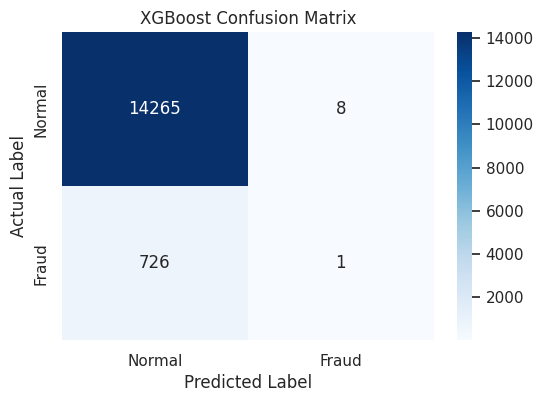

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Normal","Fraud"],yticklabels=["Normal","Fraud"])

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.title("XGBoost Confusion Matrix")

plt.show()

classification **report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred,target_names=["Normal","Fraud"]))

              precision    recall  f1-score   support

      Normal       0.95      1.00      0.97     14273
       Fraud       0.11      0.00      0.00       727

    accuracy                           0.95     15000
   macro avg       0.53      0.50      0.49     15000
weighted avg       0.91      0.95      0.93     15000



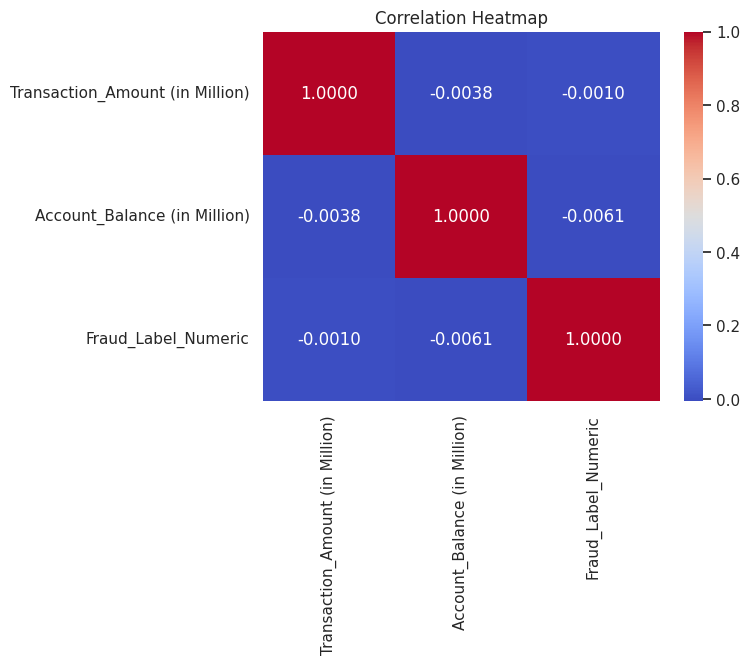

In [ ]:
corr = df[["Transaction_Amount (in Million)","Account_Balance (in Million)","Fraud_Label_Numeric"]].corr()
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".4f")
plt.title("Correlation Heatmap")

plt.show()

In [ ]:
display(feature_importances.head(15))

,Feature,Importance
0,Unusual_Time_Transaction_Yes,0.069001
1,Is_International_Transaction_Yes,0.062674
2,Card_Type_Debit,0.029050
3,Customer_Home_Location_Lahore,0.028915
4,Transaction_Location_Faisalabad,0.027807
5,Previous_Fraud_Count,0.027179
6,Failed_Transaction_Count,0.026920
7,Customer_Home_Location_Multan,0.026661
8,Transaction_Location_Lahore,0.026506
9,month,0.026475


In [ ]:
customer_id_to_search = 24239 # @param {type: "number"}

specific_customer_transactions = df[df['Customer_ID'] == customer_id_to_search]
display(specific_customer_transactions)

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label,Fraud_Label_Numeric,Anomaly
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal,0.0,1


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import numpy as np # Ensure numpy is imported for np.number in select_dtypes

# Make a copy of the dataframe to avoid modifying the original 'df'
df_for_isolation = df.copy()

# Define features and columns to drop for IsolationForest
# All numerical features that need scaling
numerical_features_iso = [
    'Transaction_Amount (in Million)', 'Previous_Fraud_Count', 'Failed_Transaction_Count',
    'Distance_From_Home', 'Daily_Transaction_Count', 'Account_Balance (in Million)',
    'Weekly_Transaction_Count', 'Avg_Transaction_Amount (in Million)',
    'Max_Transaction_Last_24h (in Million)'
]

# All categorical features that need one-hot encoding
categorical_features_iso = [
    'Unusual_Time_Transaction', 'Is_International_Transaction', 'Is_New_Merchant',
    'Transaction_Type', 'Merchant_Category', 'Transaction_Location',
    'Customer_Home_Location', 'Card_Type'
]

# Columns to drop (IDs, string timestamps, target labels, or irrelevant to anomaly detection)
columns_to_drop_iso = [
    'Transaction_ID', 'Customer_ID', 'Merchant_ID', 'Device_ID', 'IP_Address',
    'Transaction_Time', 'Transaction_Date', 'Fraud_Label', 'Fraud_Label_Numeric'
]

# Drop specified columns before preprocessing to ensure no problematic columns reach the pipeline
existing_columns_to_drop = [col for col in columns_to_drop_iso if col in df_for_isolation.columns]
df_for_isolation = df_for_isolation.drop(columns=existing_columns_to_drop, errors='ignore')

# Handle potential missing values in df_for_isolation before pipeline
# Impute numerical features with median
for col in numerical_features_iso:
    if col in df_for_isolation.columns and df_for_isolation[col].isnull().any():
        df_for_isolation[col].fillna(df_for_isolation[col].median(), inplace=True)

# Impute categorical features with mode
for col in categorical_features_iso:
    if col in df_for_isolation.columns and df_for_isolation[col].isnull().any():
        df_for_isolation[col].fillna(df_for_isolation[col].mode()[0], inplace=True)

# Create a column transformer for preprocessing using the refined feature lists
preprocessor_iso = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_iso),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_iso)
    ],
    remainder='drop' # Explicitly drop any remaining columns not handled, ensuring all input is numeric
)

# Build the pipeline with preprocessing and Isolation Forest
model_pipeline_iso = Pipeline(steps=[
    ('preprocessor', preprocessor_iso),
    ('iso', IsolationForest(contamination=0.05, random_state=42))
])

# Fit the pipeline and predict anomalies using the prepared dataframe
df['Anomaly'] = model_pipeline_iso.fit_predict(df_for_isolation)

# -1 = anomaly (potential fraud)


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/FraudShield_Banking_Data.csv')

# Create risk features
df['Location_Mismatch'] = (df['Transaction_Location'] != df['Customer_Home_Location']).astype(int)
df['High_Distance'] = (df['Distance_From_Home'] > 400).astype(int)

# Composite Fraud Risk Score (0 to 1 scale)
df['Fraud_Risk_Score'] = (
    (df['Unusual_Time_Transaction'] == 'Yes') * 0.30 +
    (df['Is_International_Transaction'] == 'Yes') * 0.30 +
    (df['Previous_Fraud_Count'] >= 1) * 0.15 +
    (df['Is_New_Merchant'] == 'Yes') * 0.10 +
    (df['Failed_Transaction_Count'] >= 2) * 0.08 +
    (df['High_Distance'] == 1) * 0.07
)

# Classification thresholds
df['Predicted_Label'] = np.where(df['Fraud_Risk_Score'] > 0.65, 'Fraud', 'Normal')

print(df['Predicted_Label'].value_counts())
print("\nHigh Risk Transactions:")
print(df[df['Fraud_Risk_Score'] > 0.7][['Transaction_ID', 'Fraud_Risk_Score']].head())

Predicted_Label
Normal    38158
Fraud     11842
Name: count, dtype: int64

High Risk Transactions:
    Transaction_ID  Fraud_Risk_Score
2         223410.0              0.75
13        574874.0              0.85
15        521551.0              0.93
21        589323.0              0.92
30        130850.0              0.75


## Analyzing High Risk Transactions Dataset

In [ ]:
df_high_risk = pd.read_csv('/content/High_Risk_Transactions.csv')
display(df_high_risk.head())

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Repeat_Offender,High_Failed,International_Unusual,Fraud_Risk_Score,Rule_Based_Label,Anomaly_Score,Isolation_Pred,Isolation_Label,Final_Risk_Score,Final_Label
0,868314.0,20372.0,1.0,04:48,2025-01-22,Online,66027.0,Grocery,Multan,Karachi,...,1,1,1,1.0,Fraud,0.597342,-1,Fraud,0.798671,Fraud
1,668951.0,41241.0,9.0,13:06,2025-04-23,ATM,76232.0,ATM,Dubai,Islamabad,...,1,1,1,1.0,Fraud,0.595629,-1,Fraud,0.797815,Fraud
2,969424.0,51763.0,1.0,23:08,2025-02-02,POS,28032.0,Grocery,Kuala Lumpur,Islamabad,...,1,1,1,1.0,Fraud,0.595174,-1,Fraud,0.797587,Fraud
3,863417.0,70515.0,1.0,20:07,2025-04-11,ATM,18539.0,Restaurant,Multan,Islamabad,...,1,1,1,1.0,Fraud,0.594486,-1,Fraud,0.797243,Fraud
4,684677.0,36445.0,1.0,14:15,2025-03-12,Online,93018.0,Fuel,Singapore,Karachi,...,1,1,1,1.0,Fraud,0.593679,-1,Fraud,0.796840,Fraud


In [ ]:
display(df_high_risk.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 37 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_ID                         2500 non-null   float64
 1   Customer_ID                            2499 non-null   float64
 2   Transaction_Amount (in Million)        2500 non-null   float64
 3   Transaction_Time                       2499 non-null   object 
 4   Transaction_Date                       2500 non-null   object 
 5   Transaction_Type                       2499 non-null   object 
 6   Merchant_ID                            2500 non-null   float64
 7   Merchant_Category                      2500 non-null   object 
 8   Transaction_Location                   2500 non-null   object 
 9   Customer_Home_Location                 2500 non-null   object 
 10  Distance_From_Home                     2500 non-null   float64
 11  Devi

None

## Missing Values Analysis for High Risk Transactions

In [ ]:
missing_values_high_risk = df_high_risk.isnull().sum()
missing_values_high_risk = missing_values_high_risk[missing_values_high_risk > 0].sort_values(ascending=False)
display(missing_values_high_risk)

,0
Customer_ID,1
Transaction_Time,1
Transaction_Type,1
Avg_Transaction_Amount (in Million),1
Failed_Transaction_Count,1


## Imputing Missing Values in High Risk Transactions

In [ ]:
for col in ['Customer_ID', 'Avg_Transaction_Amount (in Million)', 'Failed_Transaction_Count']:
    if col in df_high_risk.columns and df_high_risk[col].isnull().any():
        df_high_risk[col].fillna(df_high_risk[col].median(), inplace=True)

for col in ['Transaction_Time', 'Transaction_Type']:
    if col in df_high_risk.columns and df_high_risk[col].isnull().any():
        df_high_risk[col].fillna(df_high_risk[col].mode()[0], inplace=True)

print("Missing values after imputation:")
display(df_high_risk.isnull().sum()[df_high_risk.isnull().sum() > 0])

Missing values after imputation:


,0


## Feature Engineering for High Risk Transactions

In [ ]:
df_high_risk = pd.read_csv('/content/High_Risk_Transactions.csv')

In [ ]:
df_high_risk = pd.read_csv('/content/High_Risk_Transactions.csv')
df_high_risk['Transaction_Date'] = pd.to_datetime(df_high_risk['Transaction_Date'])
df_high_risk['day_of_week'] = df_high_risk['Transaction_Date'].dt.dayofweek
df_high_risk['month'] = df_high_risk['Transaction_Date'].dt.month
df_high_risk['day'] = df_high_risk['Transaction_Date'].dt.day
df_high_risk['Transaction_Time_Hour'] = pd.to_datetime(df_high_risk['Transaction_Time'], format='%H:%M').dt.hour

df_high_risk = df_high_risk.drop(columns=['Transaction_Date', 'Transaction_Time'])

print("DataFrame after feature engineering and dropping original time columns:")
display(df_high_risk.head())

DataFrame after feature engineering and dropping original time columns:


,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,Distance_From_Home,Device_ID,...,Rule_Based_Label,Anomaly_Score,Isolation_Pred,Isolation_Label,Final_Risk_Score,Final_Label,day_of_week,month,day,Transaction_Time_Hour
0,868314.0,20372.0,1.0,Online,66027.0,Grocery,Multan,Karachi,577.0,324855.0,...,Fraud,0.597342,-1,Fraud,0.798671,Fraud,2,1,22,4.0
1,668951.0,41241.0,9.0,ATM,76232.0,ATM,Dubai,Islamabad,571.0,363618.0,...,Fraud,0.595629,-1,Fraud,0.797815,Fraud,2,4,23,13.0
2,969424.0,51763.0,1.0,POS,28032.0,Grocery,Kuala Lumpur,Islamabad,580.0,298885.0,...,Fraud,0.595174,-1,Fraud,0.797587,Fraud,6,2,2,23.0
3,863417.0,70515.0,1.0,ATM,18539.0,Restaurant,Multan,Islamabad,539.0,519439.0,...,Fraud,0.594486,-1,Fraud,0.797243,Fraud,4,4,11,20.0
4,684677.0,36445.0,1.0,Online,93018.0,Fuel,Singapore,Karachi,504.0,615768.0,...,Fraud,0.593679,-1,Fraud,0.796840,Fraud,2,3,12,14.0


### Descriptive Statistics for High Risk Transactions

In [ ]:
display(df_high_risk.describe())

### Fraud Label Distribution in High Risk Transactions

In [ ]:
print("Distribution of Fraud_Label in df_high_risk:")
display(df_high_risk["Fraud_Label"].value_counts())

fia_percentage_high_risk = round((df_high_risk["Fraud_Label"].value_counts().get('Fraud', 0) / df_high_risk.shape[0]) * 100, 2)
print(f"\nPercentage of fraudulent transactions in df_high_risk: {fia_percentage_high_risk}%")

### Transaction Amount Analysis in High Risk Transactions

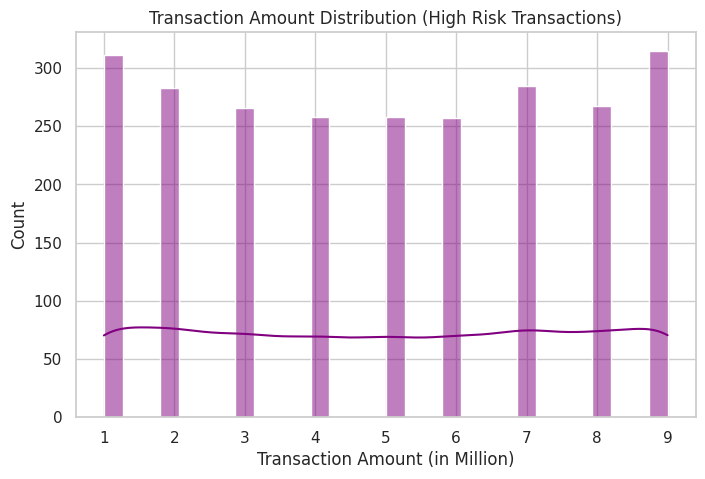

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_high_risk["Transaction_Amount (in Million)"], bins=30, kde=True, color="purple")
plt.title("Transaction Amount Distribution (High Risk Transactions)")
plt.xlabel("Transaction Amount (in Million)")
plt.ylabel("Count")
plt.show()

### Fraud Rate by Transaction Type in High Risk Transactions

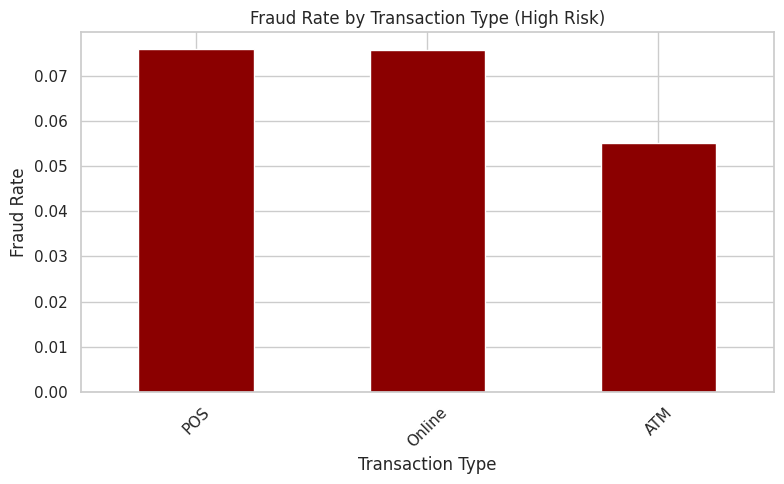

In [ ]:
# Ensure 'Fraud_Label_Numeric' exists in df_high_risk
# It was created in the main df, but df_high_risk was loaded separately.
# If not present, create it.
if 'Fraud_Label_Numeric' not in df_high_risk.columns:
    df_high_risk['Fraud_Label_Numeric'] = df_high_risk['Fraud_Label'].map({'Normal': 0, 'Fraud': 1})

fraud_by_type_high_risk = df_high_risk.groupby("Transaction_Type")["Fraud_Label_Numeric"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
fraud_by_type_high_risk.plot(kind="bar", title="Fraud Rate by Transaction Type (High Risk)", color="darkred")
plt.ylabel("Fraud Rate")
plt.xlabel("Transaction Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()